<a href="https://colab.research.google.com/github/hajyhia/Airbnb_Berlin_Price_predic/blob/main/03_Airbnb_Berlin_EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# !pip install missingno
# !pip install geopy
# !pip install matplotlib

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# from pandas_profiling import ProfileReport
import numpy as np
import missingno as msno
sns.set()
# plt.style.use('ggplot')
plt.style.use('seaborn-v0_8')
import warnings
import datetime as dt

from sklearn import ensemble, tree, linear_model
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

from scipy.stats import pearsonr
from scipy.stats import ks_2samp
from scipy.stats import norm
from scipy import stats
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Ignore warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df_EDA2 = pd.read_pickle('/content/drive/My Drive/Airbnb/df_EDA2.pkl')


## Declare data columns Lists

In [6]:
numerical_columns = ['Accomodates', 'Bathrooms', 'Bedrooms', 'Beds', 'Guests Included','Min Nights','Reviews','Price']
rating_columns = ['Value Rating','Location Rating', 'Cleanliness Rating','Checkin Rating','Accuracy Rating','Communication Rating','Host Response Rate','Overall Rating']
boolean_columns = ['Is Superhost','Is Exact Location', 'Instant Bookable']
categorical_columns = ['Room Type','Property Type Reduced','Neighborhood Group','Postal Code Reduced','Host Response Time'] # , 'Neighbourhood Grouped'
categorical_encoded_columns = ['Room Type Encoded','Property Type Reduced Encoded','Neighborhood Group Encoded','Postal Code Reduced Encoded','Host Response Time Encoded']
date_columns = ['review_date','Host Since']
geo_columns = ['Latitude','Longitude']
num_non_dummy_columns = numerical_columns + rating_columns + categorical_encoded_columns + geo_columns

dropping 'Listing ID'and duplciated'Neighbourhood Grouped'

In [7]:
df = df_EDA2.copy()
df = df.drop(columns=['review_date']) ## , 'Host Since'

In [8]:
df.shape, df.index[-1]

((23460, 32), np.int64(23535))

In [9]:
df.reset_index(drop=True, inplace=True)
df.shape, df.index[-1]

((23460, 32), 23459)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23460 entries, 0 to 23459
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Accuracy Rating        18862 non-null  float64
 1   Bathrooms              23431 non-null  float64
 2   Checkin Rating         18844 non-null  float64
 3   Cleanliness Rating     18866 non-null  float64
 4   Communication Rating   18860 non-null  float64
 5   Host Response Rate     12984 non-null  float64
 6   Latitude               23460 non-null  float64
 7   Location Rating        18845 non-null  float64
 8   Longitude              23460 non-null  float64
 9   Overall Rating         18888 non-null  float64
 10  Price                  23460 non-null  float64
 11  Square Feet            425 non-null    float64
 12  Value Rating           18842 non-null  float64
 13  Comments               19350 non-null  object 
 14  Host Since             23440 non-null  object 
 15  Ho

In [11]:
df_num = df._get_numeric_data().dropna()
df_num.shape

(297, 22)

## Outliers

The box extends from the first quartile (Q1) to the third quartile (Q3) of the data, with a line at the median. The whiskers extend from the box to the farthest data point lying within 1.5x the inter-quartile range (IQR) from the box. Flier points are those past the end of the whiskers. See

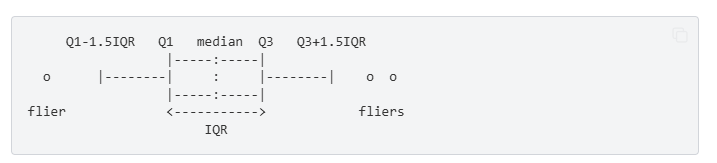

In [12]:
df_num_non_dummy = df_num.drop(columns=boolean_columns)
num_non_dummy_columns = df_num_non_dummy.columns
df_num_non_dummy.shape
num_non_dummy_columns

Index(['Accuracy Rating', 'Bathrooms', 'Checkin Rating', 'Cleanliness Rating',
       'Communication Rating', 'Host Response Rate', 'Latitude',
       'Location Rating', 'Longitude', 'Overall Rating', 'Price',
       'Square Feet', 'Value Rating', 'Accomodates', 'Bedrooms', 'Beds',
       'Guests Included', 'Min Nights', 'Reviews'],
      dtype='object')

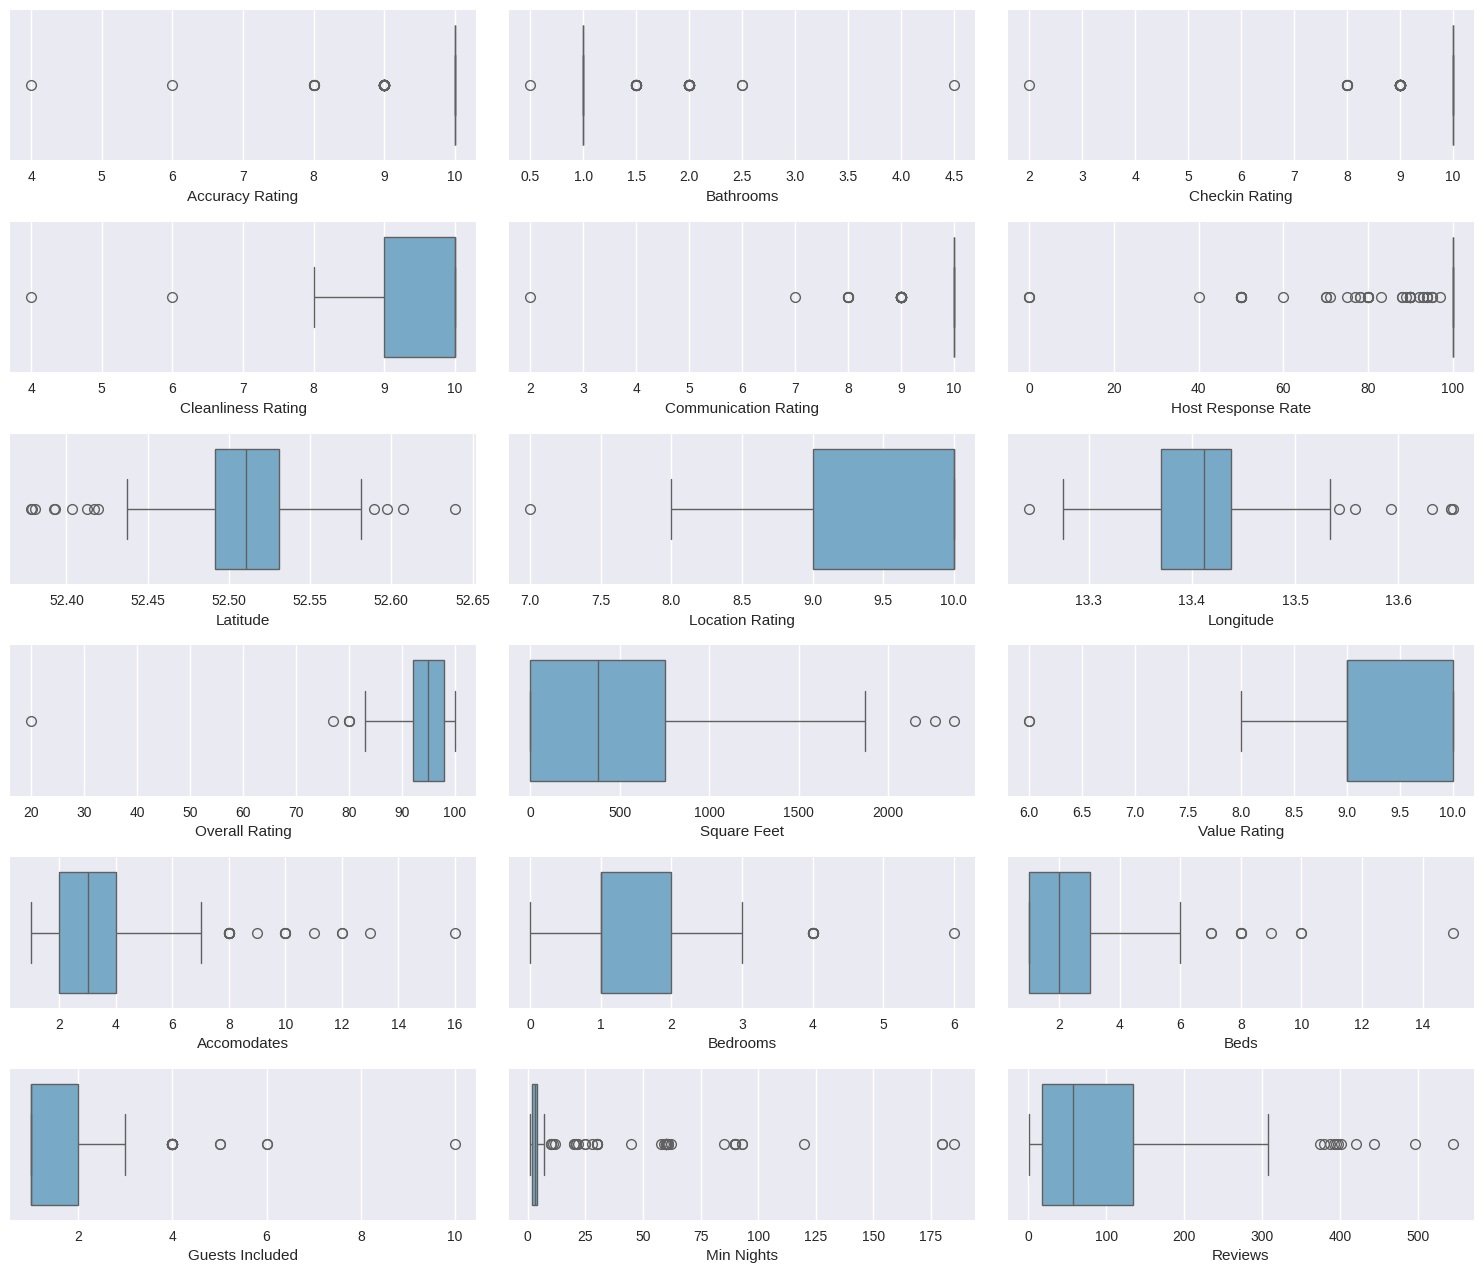

In [13]:
def outlier_boxplot(df):
  plt.figure(figsize=(15, 40))
  j = 1
  r = len(df.columns)
  for i, col in enumerate([c for c in df if c != 'Price'], 1):
    plt.subplot(r, 3, i)
    sns.boxplot(x=df[col].dropna(), palette='Blues')
    plt.subplots_adjust(hspace = 0.6)

  plt.tight_layout()
  plt.show()

outlier_boxplot(df_num_non_dummy)

The boxplots reveal potential outliers in several numerical features, particularly:

1. Price: Ignored as it is the target value
2. Reviews: Some listings have significantly higher review counts than others.
3. Bedrooms, Bathrooms, Beds, Accommodates: Some properties might have unrealistic values (e.g., too many or too few bedrooms relative to accommodations).

In [14]:
def df_describe(df, numerical_columns):
  min_vals = []
  max_vals = []
  Q1_ = []
  Q2_ = []
  Q3_ = []
  IQR_ = []
  lower_bound_ = []
  upper_bound_ = []
  for column in df_num_non_dummy:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.50)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    min_vals.append(df[column].min())
    max_vals.append(df[column].max())
    Q1_.append(Q1)
    Q2_.append(Q2)
    Q3_.append(Q3)
    IQR_.append(IQR)
    lower_bound_.append(lower_bound)
    upper_bound_.append(upper_bound)

  # return pd.DataFrame(data = [min_vals, lower_bound_,Q1_,Q2_,Q3_ ,IQR_,upper_bound_,max_vals],
  #            columns=["min_vals", "lower_bound","Q1","Q2","Q3","IQR","upper_bound","max_vals"])
  return pd.DataFrame({
      'min': min_vals,
      'Q1(25%)': Q1_,
      'Q2(50%)': Q2_,
      'Q3(75%)': Q3_,
      'max': max_vals,
      'IQR': IQR_,
      'lower_bound': lower_bound_,
      'upper_bound': upper_bound_}, index=num_non_dummy_columns)

df_describe(df_num_non_dummy, num_non_dummy_columns)

,min,Q1(25%),Q2(50%),Q3(75%),max,IQR,lower_bound,upper_bound
Accuracy Rating,4.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Bathrooms,0.50000,1.00000,1.00000,1.00000,4.50000,0.00000,1.000000,1.000000
Checkin Rating,2.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Cleanliness Rating,4.00000,9.00000,10.00000,10.00000,10.00000,1.00000,7.500000,11.500000
Communication Rating,2.00000,10.00000,10.00000,10.00000,10.00000,0.00000,10.000000,10.000000
Host Response Rate,0.00000,100.00000,100.00000,100.00000,100.00000,0.00000,100.000000,100.000000
Latitude,52.37828,52.49150,52.51037,52.53055,52.63913,0.03905,52.432925,52.589125
Location Rating,7.00000,9.00000,10.00000,10.00000,10.00000,1.00000,7.500000,11.500000
Longitude,13.24245,13.37033,13.41194,13.43787,13.65275,0.06754,13.269020,13.539180
Overall Rating,20.00000,92.00000,95.00000,98.00000,100.00000,6.00000,83.000000,107.000000


## Data Cleansing

### outliers_df

Based on previous histograms and skewness visualizations, we can observe that the data is not normally distributed. To identify outliers, we will apply the IQR method, establishing boundaries before Q1 and after Q3. Any values falling outside these boundaries will be considered outliers.

In [15]:
def count_outliers_df(df):
    total_outliers = pd.DataFrame(columns=['Outlier count', 'Percent'])
    # for col in df:  # Ensure processing numeric columns only
    for col in [c for c in df if c != 'Price']:  # Ensure processing numeric columns only and exclude Price
        temp = pd.DataFrame(df[col])
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        # Filter rows that are outliers in either direction
        temp_outliers = temp[(temp[col] > upper_limit) | (temp[col] < lower_limit)]
        num_outliers = len(temp_outliers)
        total_outliers.loc[col] = [num_outliers, num_outliers / len(df) * 100]

    return total_outliers[total_outliers['Percent'] > 0]

**Consider replacing outliers_df dataframe with only outliers_df_columns**

In [16]:
len(df_num_non_dummy.columns)

19

In [17]:
# Assume df_num_non_dummy is your DataFrame
# Call the function and sort results
outliers_df = count_outliers_df(df_num_non_dummy).sort_values('Percent', ascending=False)
outliers_df, outliers_df.shape

(                      Outlier count    Percent
 Accuracy Rating                74.0  24.915825
 Checkin Rating                 60.0  20.202020
 Host Response Rate             56.0  18.855219
 Min Nights                     53.0  17.845118
 Bathrooms                      52.0  17.508418
 Communication Rating           51.0  17.171717
 Guests Included                26.0   8.754209
 Accomodates                    20.0   6.734007
 Latitude                       13.0   4.377104
 Reviews                        11.0   3.703704
 Beds                           10.0   3.367003
 Bedrooms                        9.0   3.030303
 Longitude                       8.0   2.693603
 Overall Rating                  5.0   1.683502
 Square Feet                     3.0   1.010101
 Cleanliness Rating              2.0   0.673401
 Value Rating                    2.0   0.673401
 Location Rating                 1.0   0.336700,
 (18, 2))

In [ ]:
outliers_df.to_csv('/content/drive/My Drive/Airbnb/outliers_df.csv')

### new_df_outliers - labeling with 'Outlier'
Labeling every outlier with 'Outlier'

In [ ]:
outliers_df.index

In [ ]:
def outliers(df):
    label_out_df = df.copy()
    for col in label_out_df:
        if col in outliers_df.index:
            Q1 = label_out_df[col].quantile(0.25)
            Q3 = label_out_df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            label_out_df[col] = np.where(label_out_df[col] > upper_limit, 'Outlier',
                                         np.where(label_out_df[col] < lower_limit,
                                                  'Outlier', label_out_df[col]))
    return label_out_df

new_df_outliers = outliers(df)
new_df_outliers.head(5)

### df_outliers - 0/1

Creating a dataframe with outliers as 1 and non-outliers as 0:

In [ ]:
df_outliers = new_df_outliers.isin(['Outlier'])
df_outliers = df_outliers.astype('int')
df_outliers

Now that we have a dataframe saving all the outliers we'll convert all the outliers to nulls, just so I can see differences in distribution with and without outliers and then decide which of the outliers to remove or not:

In [ ]:
def capping(df):
    temp = df.copy()
    for col in temp:
        if col in outliers_df.index:
            Q1 = temp[col].quantile(0.25)
            Q3 = temp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_limit = Q1 - 1.5 * IQR
            upper_limit = Q3 + 1.5 * IQR
            temp[col] = np.where(temp[col] > upper_limit,np.nan,np.where(temp[col] < lower_limit,np.nan,temp[col]))
    return temp
temp = capping(df)
temp

In [ ]:
temp.to_csv('/content/drive/My Drive/Airbnb/outliers_q_df.csv')

In [ ]:
def dist_outliers(original_df, new, cols):
  for col in df_num_non_dummy:
      if col in cols:
        plt.figure(figsize=(14,5))

        plt.subplot(2,2,1)
        sns.distplot(original_df[col].dropna(), color='orange')
        plt.title('{} Distribution before capping'.format(col), fontsize=15)

        plt.subplot(2,2,2)
        sns.boxplot(x=original_df[col].dropna(), color='orange')
        plt.subplots_adjust(hspace = 0.6)

        plt.subplot(2,2,3)
        sns.distplot(new[col].dropna())
        plt.title('{} Distribution after capping'.format(col), fontsize=15)

        plt.subplot(2,2,4)
        sns.boxplot(x=new[col].dropna(), palette='Blues')
        plt.subplots_adjust(hspace = 0.6)

        plt.tight_layout()
        plt.show()

dist_outliers(df, temp, outliers_df.index)

We clearly need to filter some features that either the feature distribution has changed significantly, or cases where removing outliers results with only one value.

Checking if distribution (Kolmogorov–Smirnov) and/or correlation has changed significantly:

In [ ]:
corr_mattrix = df[['Price', 'Reviews']].corr(method='spearman')
corr_mattrix.Price.loc['Reviews']

In [ ]:
df['Price'].corr(df['Reviews'], method='spearman')

In [ ]:
### differences between two correlation in Python: https://github.com/psinger/CorrelationStats
### We will only take from the code the Fisher method for two-tailed test
### Z-test to Compare Two Correlations???
def cocor(x1,y1, x2,y2):
    xy1 = x1.corr(y1, method='spearman')
    xy2 = x2.corr(y2, method='spearman')
    n1 = len(x1)
    n2 = len(x2)
    xy_z = 0.5 * np.log((1 + xy1)/(1 - xy1))
    ab_z = 0.5 * np.log((1 + xy2)/(1 - xy2))
    if n2 is None:
        n2 = n1
    se_diff_r = np.sqrt(1/(n1 - 3) + 1/(n2 - 3))
    diff = xy_z - ab_z
    z_score = abs(diff / se_diff_r)
    p_value = (1 - norm.cdf(z_score)) * 2
    return z_score, p_value

In [ ]:
c=df_num_non_dummy.drop(columns=['Price'])
names=c.columns
#Creating df that reflects the correlation change
out_df= pd.DataFrame(columns=['feature','outliers_cnt','distribution_changed','correlation_changed'])

#A copy of numeric df
no_outliers=df_num_non_dummy.copy()
np.seterr(divide='ignore', invalid='ignore')
for i in names:
    # df with outliers
    out=df[i]
    # df with out outliers
    non=df[i].loc[new_df_outliers[i]==0]
    # lable with outliers
    price_out=df['Price']
    # lable with out outliers
    price_non=df['Price'].loc[new_df_outliers[i]==0]
    # cocor pvalue
    p, pvalue = cocor(out,price_out, non,price_non)
    cor_change=np.where(pvalue<0.05,'+','-')
    # outliers count
    mv=df_outliers.sum()
    # ks pvalue
    pval=ks_2samp(out, non)[1]
    dist_change=np.where(pval<0.05,'+','-')
    out_df = pd.concat([out_df, pd.DataFrame([{'feature':i,'outliers_cnt':mv,'distribution_changed':dist_change,'correlation_changed': cor_change}])], ignore_index=True)
out_df.head(20)

In [ ]:
#All 'Yes' Vars in the 'Drop'colums shall be deleted, since the infect correlation and distribution.
#We don't want to delete vars that will change the distribution
out_df['drop']='yes'
out_df.loc[(out_df.distribution_changed=='+')& (out_df.correlation_changed=='+'),'drop'] = 'no'
out_df

In [ ]:
out_df.groupby('drop').size()

There are 20 features in total where removal of the outliers does not affect neither correlation nor distribution. And 17 features that shall be removed.

In [ ]:
relevant_columns_features=out_df.loc[out_df['drop']=='yes']['feature']
relevant_columns_features

In [ ]:
relevant_columns_features.values

Will only select the following columns to remove

In [ ]:
remove_outliers=['Bathrooms', 'Accomodates', 'Min Nights', 'Host Response Rate']
remove_outliers

Removing outleirs that don't change correlation

In [ ]:
manipulated_data= df.copy()
for index, row in df_outliers.iterrows():  # Iterate through df_outliers with index
    for col in remove_outliers:
        if row[col] == 1:
            manipulated_data.loc[index,col] = np.nan ## 0  # Use the index from df_outliers

In [ ]:
manipulated_data.columns

In [ ]:
manipulated_data.to_csv('/content/drive/My Drive/Airbnb/manipulated_data_no_outleirs.csv')

# Missing Values

In [ ]:
def missing_columns_df(df):
  df_nulls = df.copy()
  for col in df_nulls:
      if df_nulls[col].isna().sum() == 0:
          del df_nulls[col]
  return df_nulls

df_nulls = missing_columns_df(manipulated_data)
df_nulls

In [ ]:
msno.matrix(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

In [ ]:
msno.bar(df_nulls, figsize=(15, 5), fontsize=10, color=(0.8, 0.6, 0.2));

In [ ]:
def missing_values_table(df):
  mis_val = df.isna().sum()
  mis_val_per = mis_val/len(df)*100
  mis_val_table = pd.concat([mis_val, mis_val_per], axis=1)
  mis_val_table_ren_columns = mis_val_table.rename(columns = {0 : 'Missing Values', 1 : '% of Total Values'})
  mis_val_table_ren_columns = mis_val_table_ren_columns[mis_val_table_ren_columns.iloc[:,:] != 0].sort_values(
      '% of Total Values', ascending=False).round(1)
  return mis_val_table_ren_columns

mis_val_table_ren_columns = missing_values_table(df_nulls)
mis_val_table_ren_columns

Creating a dataframe with missing values as 1 and existing values as 0:

In [ ]:
df_missing_data = manipulated_data.isin([np.nan])
df_missing_data = df_missing_data.astype('int')
df_missing_data

Creating df including numeric features of the later data - manipulated_data

In [ ]:
#Selecting numeric data
numeric_manipulated_data = manipulated_data.select_dtypes(include=[np.number])
numeric_manipulated_data.columns

## Exploring data

Difference in the distribution of a variable when another variable is with or without MV:

In [ ]:
#c = numeric_manipulated_data.columns
colist = df_nulls.columns
#names = missing_names
#sns.set(font_scale = 0.8)
#sns.set_style("whitegrid")
sns.set_style("ticks")
sns.set
a=len(colist)
b=2
c=1
fig = plt.figure(figsize=(15,60))
plt.subplots_adjust(hspace=0.5)
for j in df_nulls:
    plt.subplot(a,b,c)
    plt.title('{}'.format(j),fontsize=12)
    plt.xlabel(i)
    sns.kdeplot(df['Latitude'],fill=True)
    sns.kdeplot(df['Latitude'].loc[df_missing_data[j]==0],fill=True,color='orange')
    c=c+1

plt.show()

Exploring data of the segnificunce of distribution change:

In [ ]:
#le = preprocessing.LabelEncoder()
MV_df_final = pd.DataFrame(columns= ['Var', 'MV_pct', 'distribution_changed', 'pval'])
#df[m] = le.fit_transform(df[m].astype(str))
m=numeric_manipulated_data.copy()
#m = manipulated_data._get_numeric_data().columns.dropna().unique()
np.seterr(divide='ignore', invalid='ignore')
for i in df_nulls:
    # and i in mis_val_table_ren_columns.index.tolist():
    # column with NULLS
        null = m['Latitude'] ##.loc[df_missing_data[i]==1]
    # column without NULLS
        non = m['Latitude'].loc[df_missing_data[i]==0]
    # target value with NULLS
        price_null = m['Price']
    # target value without NULLS
        price_non = price_null.loc[df_missing_data[i]==0]
        mv = df_missing_data[i].sum()
    # perform Kolmogorov-Smirnov test
        pval = ks_2samp(null, non)[1]
        dis_change = np.where(pval<0.05,'+','-')
        # MV_df_final = pd.concat([MV_df_final, pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change}, index=[0])], ignore_index=True)
        temp_df = pd.DataFrame({'Var': i, 'MV_pct': mv, 'distribution_changed': dis_change, 'pval': pval}, index=[0])
        # Concatenate the temporary DataFrame to the final DataFrame
        MV_df_final = pd.concat([MV_df_final, temp_df], ignore_index=True)
        MV_df_final = MV_df_final[MV_df_final['MV_pct'] > 0]

        ## Plot KDE for comparison
        plt.figure(figsize=(10, 5))
        sns.kdeplot(null, label="is NaN", fill=True, alpha=0.5, color='blue')
        sns.kdeplot(non, label="is NOT NaN", fill=True, alpha=0.5, color='red')
        plt.title(f"Distribution of Missingness of '{i}' , P-Value = {pval}, Missing= {mv}")
        plt.legend()
        plt.show()
MV_df_final

Original

In [ ]:
MV_df_final['drop']= 'Yes'
MV_df_final['MV_type']= 'MCAR/MAR'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'drop']='No'
MV_df_final.loc[(MV_df_final.distribution_changed== '+'),'MV_type']='MNAR'
MV_df_final = MV_df_final[MV_df_final['MV_pct']>0].sort_values(by='MV_pct', ascending=False)
MV_df_final

# Data Imputation

Although the columns were recommended for removal, we will go over teh columns one by one.

In [ ]:
mis_val_table_ren_columns

In [ ]:
df_final = manipulated_data

In [ ]:
manipulated_data.index[-1]

In [ ]:
manipulated_data.reset_index(drop=True, inplace=True)

In [ ]:
df_nulls.columns

1. We will delete 'Host Response Rate' since the missing is nearly 50%, however we will try to keep 'Host Response Time', cause we might use it later

In [ ]:
del df_final['Host Response Rate']
del df_final['Square Feet']

2. We will categorize the missing values of dummies and categorial values: host_has_profile_pic, host_identity_verified, host_is_superhost, host_response_time, host_neighbourhood, host_location.
2.1 Transporing missing values of 3 categorial columns into additional categoey 'Missing'

In [ ]:
#host_response_time
# df_final['Host Response Time'] = df_final.apply(lambda row: row['Host Response Time'] if type(row['Host Response Time']) == str else 'missing', axis=1)
df_final['Host Response Time'] = df_final['Host Response Time'].apply(lambda x: x if type(x) == str else 'missing')
df_final['Host Response Time'].isnull().sum()

In [ ]:
#host_response_time
df_final['Comments'] = df_final['Comments'].apply(lambda x: x if type(x) == str else 'missing')
df_final['Comments'].isnull().sum()

In [ ]:
missing_values_table(missing_columns_df(df_final))

### Use KNN

The rest of the data is below 40% missing. hense we can imput. we will use KNN

In [ ]:
final_df = df_final.copy()
imp_cols = final_df.select_dtypes(include = ['float64', 'int64']).columns
imp_cols = [col for col in imp_cols if col not in ['Longitude', 'Latitude']]
imp_cols

In [ ]:
final_df['Accomodates']

In [ ]:
import math
math.sqrt(math.sqrt(len(final_df)))

In [ ]:
from sklearn.impute import KNNImputer
# metric='nan_euclidean'
knn_imputer = KNNImputer(n_neighbors=11, metric='nan_euclidean')
imputed_data = pd.DataFrame(knn_imputer.fit_transform(final_df[imp_cols]),columns = imp_cols)

In [ ]:
final_df[imp_cols] = imputed_data

In [ ]:
sns.heatmap(imputed_data, cmap="coolwarm")

In [ ]:
imputed_data['Overall Rating'].notna().sum()

In [ ]:
print(f"df_final: {df_final.shape}, last_index: {df_final.index[-1]}")
print(f"final_df: {final_df.shape}, last_index: {final_df.index[-1]}")
print(f"imputed_data: {imputed_data.shape}, last_index: {imputed_data.index[-1]}")

In [ ]:
df_final.loc[df_final.index[-1]]

In [ ]:
# imputed_data.dropna(inplace=True)

In [ ]:
imputed_data

In [ ]:
# final_df.loc[23531]
# final_df.iloc[23531]
final_df.loc[final_df.index[-1]]
final_df.index[-1]

In [ ]:
imputed_data.loc[imputed_data.index[-1]]
imputed_data.index[-1]

In [ ]:
df_final.shape, imputed_data.index[-1]

In [ ]:
final_df.shape

In [ ]:
imputed_data.shape, final_df.shape

In [ ]:
msno.matrix(final_df, figsize=(15, 5), fontsize=10, color=(0.8, 0.5, 0.2))

# Next to Aggregation and Feature Engineering

In [ ]:
final_df.info()

In [ ]:
final_df.to_pickle("/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl")

In [ ]:
# df_Feature_Engineering = pd.read_pickle('/content/drive/My Drive/Airbnb/df_Feature_Engineering.pkl')
# df_Feature_Engineering.info()

In [ ]:
final_df[['Bedrooms', 'Beds', 'Accomodates']]

# Candidate for Trash